# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

In [ ]:
#to dump w buszu
#pip freeze > reqirements.txt

#to install dependencies 
pip install -r requirements.txt

## 1. Imports & Configuration

In [33]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import optbinning
from optbinning import BinningProcess

# Modeling
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import optuna
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)
#import lightgbm as lgb
import xgboost as xgb    # Uncomment if using XGBoost
# import catboost as cb     # Uncomment if using CatBoost
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
# Counterfactual Explanation packages
import dice_ml
# import alibi               # Uncomment when implementing Alibi

# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Random seed: 42
Data directory: C:\Users\stani\wut-counterfactual-explanations\data
Models directory: C:\Users\stani\wut-counterfactual-explanations\models


## 2. Data Loading & Feature engineering 

In [2]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
pd.set_option('display.max_columns', 500)
print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [3]:
def time_bucket(x):
    if x >= -3:
        return 'last_3m'
    elif x >= -6:
        return '3_6m'
    else:
        return 'older'

In [4]:
# load bureau data, filter by currency, drop unnecessary columns and aggregate numerical and categorical features 
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau = bureau[bureau['CREDIT_CURRENCY'] == 'currency 1']
bureau = bureau.drop(columns=['CREDIT_CURRENCY', 'SK_ID_BUREAU'])
num_cols_bureau = bureau.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
cat_cols_bureau = ['CREDIT_ACTIVE', 'CREDIT_TYPE']
num_agg_bureau = bureau.groupby('SK_ID_CURR')[num_cols_bureau].agg(['mean','max', 'sum', 'median', 'std', 'count'])
num_agg_bureau.columns = ['_'.join(col) for col in num_agg_bureau.columns]
cat_agg_bureau = pd.DataFrame(index=bureau['SK_ID_CURR'].unique())
for col in cat_cols_bureau:
    dummies = pd.get_dummies(bureau[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
    cat_agg_bureau = cat_agg_bureau.join(dummies.groupby('SK_ID_CURR').sum())
bureau_agg = num_agg_bureau.join(cat_agg_bureau)
bureau_agg = bureau_agg.reset_index()
bureau_agg = bureau_agg.rename(columns={col: f"{col}_bureau" for col in bureau_agg.columns if col != 'SK_ID_CURR'})
for col in bureau_agg.columns:
    if '_mean_' in col:
        parts = col.split('_mean_')
        feature = parts[0]
        feature_data = parts[1]
        max_col = f"{feature}_max_{feature_data}"
        std_col = f"{feature}_std_{feature_data}"
        if max_col in bureau_agg.columns:
            bureau_agg[f"{feature}_max_to_mean_{feature_data}"] = (
                bureau_agg[max_col] / (bureau_agg[col] + 1e-6)
            )
        if std_col in bureau_agg.columns:
            bureau_agg[f"{feature}_std_to_mean_{feature_data}"] = (
                bureau_agg[std_col] / (bureau_agg[col] + 1e-6)
            )

In [5]:
# load credit card balance data, drop unnecessary columns, create time buckets and aggregate numerical features
credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
credit_card_balance = credit_card_balance.drop(columns=['NAME_CONTRACT_STATUS'])
credit_card_balance['time_bucket'] = credit_card_balance['MONTHS_BALANCE'].apply(time_bucket)
credit_card_balance = credit_card_balance.drop(columns=['SK_ID_PREV'])
num_cols_credit = credit_card_balance.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
num_agg_credit = credit_card_balance.groupby(['SK_ID_CURR', 'time_bucket'])[num_cols_credit].agg(['mean', 'max', 'sum', 'median', 'std', 'count'])
num_agg_credit.columns = [
    f"{col}_{agg}_{bucket}"
    for col, agg in num_agg_credit.columns
    for bucket in ['']  
]
num_agg_credit = num_agg_credit.unstack('time_bucket')
num_agg_credit.columns = [
    f"{col}{bucket}"
    for col, bucket in num_agg_credit.columns
]
credit_agg = num_agg_credit.reset_index()
for col in credit_agg.columns:
    if '_mean_' in col:
        parts = col.split('_mean_')
        feature = parts[0]
        bucket = parts[1]
        max_col = f"{feature}_max_{bucket}"
        std_col = f"{feature}_std_{bucket}"
        if max_col in credit_agg.columns:
            credit_agg[f"{feature}_max_to_mean_{bucket}"] = (
                credit_agg[max_col] / (credit_agg[col] + 1e-6)
            )
        if std_col in credit_agg.columns:
            credit_agg[f"{feature}_std_to_mean_{bucket}"] = (
                credit_agg[std_col] / (credit_agg[col] + 1e-6)
            )

In [6]:
# load POS_CASH balance data, drop unnecessary columns, create time buckets and aggregate numerical features
pos_cash_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
pos_cash_balance = pos_cash_balance.drop(columns=['NAME_CONTRACT_STATUS'])
pos_cash_balance['time_bucket'] = pos_cash_balance['MONTHS_BALANCE'].apply(time_bucket)
pos_cash_balance = pos_cash_balance.drop(columns=['SK_ID_PREV'])
num_cols_pos = pos_cash_balance.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
num_agg_pos = pos_cash_balance.groupby(['SK_ID_CURR', 'time_bucket'])[num_cols_pos].agg(['mean', 'max', 'sum', 'median', 'std', 'count'])
num_agg_pos.columns = [
    f"{col}_{agg}_{bucket}"
    for col, agg in num_agg_pos.columns
    for bucket in [''] 
]
num_agg_pos = num_agg_pos.unstack('time_bucket')
num_agg_pos.columns = [
    f"{col}{bucket}"
    for col, bucket in num_agg_pos.columns
]
pos_agg = num_agg_pos.reset_index()
for col in pos_agg.columns:
    if '_mean_' in col:
        parts = col.split('_mean_')
        feature = parts[0]
        bucket = parts[1]
        max_col = f"{feature}_max_{bucket}"
        std_col = f"{feature}_std_{bucket}"
        if max_col in pos_agg.columns:
            pos_agg[f"{feature}_max_to_mean_{bucket}"] = (
                pos_agg[max_col] / (pos_agg[col] + 1e-6)
            )
        if std_col in pos_agg.columns:
            pos_agg[f"{feature}_std_to_mean_{bucket}"] = (
                pos_agg[std_col] / (pos_agg[col] + 1e-6)
            )

In [7]:
# load previous application data, drop unnecessary columns, and aggregate features
previous_application = pd.read_csv(DATA_DIR / "previous_application.csv")
previous_application = previous_application.drop(columns=['SK_ID_PREV'])
num_cols_previous = previous_application.select_dtypes(include='number').columns.drop('SK_ID_CURR', errors='ignore').tolist()
cat_cols_previous = previous_application.select_dtypes(include='object').columns.drop('SK_ID_CURR', errors='ignore').tolist()
num_agg_previous = previous_application.groupby('SK_ID_CURR')[num_cols_previous].agg(['mean', 'max', 'median', 'sum', 'std', 'count'])
num_agg_previous.columns = ['_'.join(col) for col in num_agg_previous.columns]
cat_agg_previous = pd.DataFrame(index=previous_application['SK_ID_CURR'].unique())
for col in cat_cols_previous:
    dummies = pd.get_dummies(previous_application[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
    cat_agg_previous = cat_agg_previous.join(dummies.groupby('SK_ID_CURR').sum())
previous_agg = num_agg_previous.join(cat_agg_previous)
previous_agg = previous_agg.reset_index()
previous_agg = previous_agg.rename(columns={col: f"{col}_previous" for col in previous_agg.columns if col != 'SK_ID_CURR'})
for col in previous_agg.columns:
    if '_mean_' in col:
        parts = col.split('_mean_')
        feature = parts[0]
        feature_data = parts[1]
        max_col = f"{feature}_max_{feature_data}"
        std_col = f"{feature}_std_{feature_data}"
        if max_col in previous_agg.columns:
            previous_agg[f"{feature}_max_to_mean_{feature_data}"] = (
                previous_agg[max_col] / (previous_agg[col] + 1e-6)
            )
        if std_col in previous_agg.columns:
            previous_agg[f"{feature}_std_to_mean_{feature_data}"] = (
                previous_agg[std_col] / (previous_agg[col] + 1e-6)
            )

In [ ]:
# for now we skip bureau_balance and instalments_payments TODO

In [8]:
final_df = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')\
                    .merge(credit_agg, on='SK_ID_CURR', how='left') \
                    .merge(pos_agg, on='SK_ID_CURR', how='left') \
                    .merge(previous_agg, on='SK_ID_CURR', how='left')

In [ ]:
#final_df.to_csv(DATA_DIR / "final_pre_selection.csv", index=False)

In [9]:
del app_train, bureau, credit_card_balance, pos_cash_balance, previous_application
import gc
gc.collect()

42

## Feature selection 

few schemes to consider 

In [13]:
# classic woe + IV feature selection as the first step 
X = final_df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = final_df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
categorical_vars = [col for col in final_df.columns if final_df[col].dtype == 'object'] 
variable_names = X_train.columns.tolist()
custom_params = {
    "gamma": 0.1,               
    "outlier_detector": "zscore" 
}
binning_fit_params = {col: custom_params for col in variable_names}
binning_process = BinningProcess(
    variable_names=variable_names,
    categorical_variables=categorical_vars,
    binning_fit_params=binning_fit_params, 
    max_n_bins=8,          
    min_bin_size=0.05,  
    selection_criteria={"iv": {"min": 0.005}})
binning_process.fit(X_train, y_train) # important to fit only on train set to avoid data leakage
X_train_woe = binning_process.transform(X_train)
X_test_woe = binning_process.transform(X_test)

In [14]:
summary = binning_process.summary()
top_15_summary = summary.sort_values("iv", ascending=False).head(15)
print("--- Final Model: Top 15 Features ---")
print(top_15_summary[['name', 'iv']].reset_index(drop=True))

--- Final Model: Top 15 Features ---
                                      name        iv
0                             EXT_SOURCE_3  0.334562
1                             EXT_SOURCE_2  0.314303
2                             EXT_SOURCE_1  0.147214
3                DAYS_CREDIT_median_bureau   0.12174
4                  DAYS_CREDIT_mean_bureau  0.116101
5         DAYS_CREDIT_UPDATE_median_bureau  0.096341
6           DAYS_CREDIT_UPDATE_mean_bureau  0.089684
7                               DAYS_BIRTH   0.08679
8                   DAYS_CREDIT_max_bureau  0.084253
9                          AMT_GOODS_PRICE   0.08149
10       DAYS_CREDIT_ENDDATE_median_bureau  0.079426
11                         OCCUPATION_TYPE  0.078339
12  DAYS_CREDIT_ENDDATE_max_to_mean_bureau  0.070054
13                       ORGANIZATION_TYPE  0.069985
14  AMT_CREDIT_SUM_DEBT_std_to_mean_bureau  0.069914


In [11]:
#for marker in ['CNT_INSTALMENT_MATURE_CUM_max_to_mean_last_3m']:
#    print(f"\n--- Binning Table: {marker} ---")
#    table = binning_process.get_binned_variable(marker).binning_table.build()
#    display_table = table[['Bin', 'Count', 'Event', 'Event rate', 'WoE']]
#    print(display_table)

In [15]:
# usually we would drop features with IV < 0.02, there is an argument to be made to drop features with IV < 0.03
# to be considered later TODO
low_iv = summary[summary['iv'] < 0.02]['name'].tolist()
final_df_without_low_iv = final_df.drop(columns=low_iv)

In [16]:
final_df_without_low_iv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 166 entries, SK_ID_CURR to DAYS_TERMINATION_std_to_mean_previous
dtypes: float64(155), int64(5), object(6)
memory usage: 389.5+ MB


In [17]:
# classic correlation analysis to identify highly correlated pairs of features, the one with the lower IV in each pair will be removed
corr = final_df_without_low_iv.select_dtypes(include='number').corr()
pairs = corr.stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]  # drop diagonal
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]   # drop duplicates
high_corr = pairs[pairs.abs() > 0.7].sort_values(ascending=False)
to_drop = set()
for var1, var2 in high_corr[high_corr.abs() > 0.8].index:
    if var1 in to_drop or var2 in to_drop:
        continue
    # get IV for both
    iv1 = summary.loc[summary['name'] == var1, 'iv'].values[0]
    iv2 = summary.loc[summary['name'] == var2, 'iv'].values[0]
    # drop the weaker one
    if iv1 >= iv2:
        to_drop.add(var2)
    else:
        to_drop.add(var1)
print(f"Dropping {len(to_drop)} variables: {to_drop}")
final = final_df_without_low_iv.drop(columns=to_drop)

Dropping 87 variables: {'AMT_DRAWINGS_ATM_CURRENT_count_last_3m', 'AMT_DRAWINGS_ATM_CURRENT_max_to_mean_older', 'CNT_INSTALMENT_MATURE_CUM_max_3_6m', 'DAYS_CREDIT_mean_bureau', 'CNT_DRAWINGS_OTHER_CURRENT_count_last_3m', 'CNT_INSTALMENT_MATURE_CUM_median_last_3m', 'FLOORSMAX_MODE', 'DAYS_CREDIT_UPDATE_sum_bureau', 'DAYS_CREDIT_ENDDATE_max_bureau', 'AMT_RECEIVABLE_PRINCIPAL_std_to_mean_older', 'CNT_INSTALMENT_MATURE_CUM_max_last_3m', 'CNT_DRAWINGS_POS_CURRENT_count_last_3m', 'MONTHS_BALANCE_std_to_mean_older_y', 'YEARS_BEGINEXPLUATATION_AVG', 'AMT_PAYMENT_CURRENT_mean_3_6m', 'SK_DPD_count_older_y', 'DAYS_CREDIT_ENDDATE_mean_bureau', 'MONTHS_BALANCE_count_older_y', 'AMT_DRAWINGS_OTHER_CURRENT_count_older', 'DAYS_LAST_DUE_max_to_mean_previous', 'LIVINGAREA_MODE', 'DAYS_TERMINATION_std_previous', 'CNT_INSTALMENT_MATURE_CUM_sum_3_6m', 'DAYS_LAST_DUE_1ST_VERSION_std_previous', 'AMT_DRAWINGS_OTHER_CURRENT_count_last_3m', 'DAYS_ENDDATE_FACT_count_bureau', 'DAYS_DECISION_median_previous', 'AMT_

In [18]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 79 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   SK_ID_CURR                                      307511 non-null  int64  
 1   TARGET                                          307511 non-null  int64  
 2   AMT_GOODS_PRICE                                 307233 non-null  float64
 3   NAME_INCOME_TYPE                                307511 non-null  object 
 4   DAYS_BIRTH                                      307511 non-null  int64  
 5   DAYS_EMPLOYED                                   307511 non-null  int64  
 6   DAYS_REGISTRATION                               307511 non-null  float64
 7   DAYS_ID_PUBLISH                                 307511 non-null  int64  
 8   OWN_CAR_AGE                                     104582 non-null  float64
 9   OCCUPATION_TYPE           

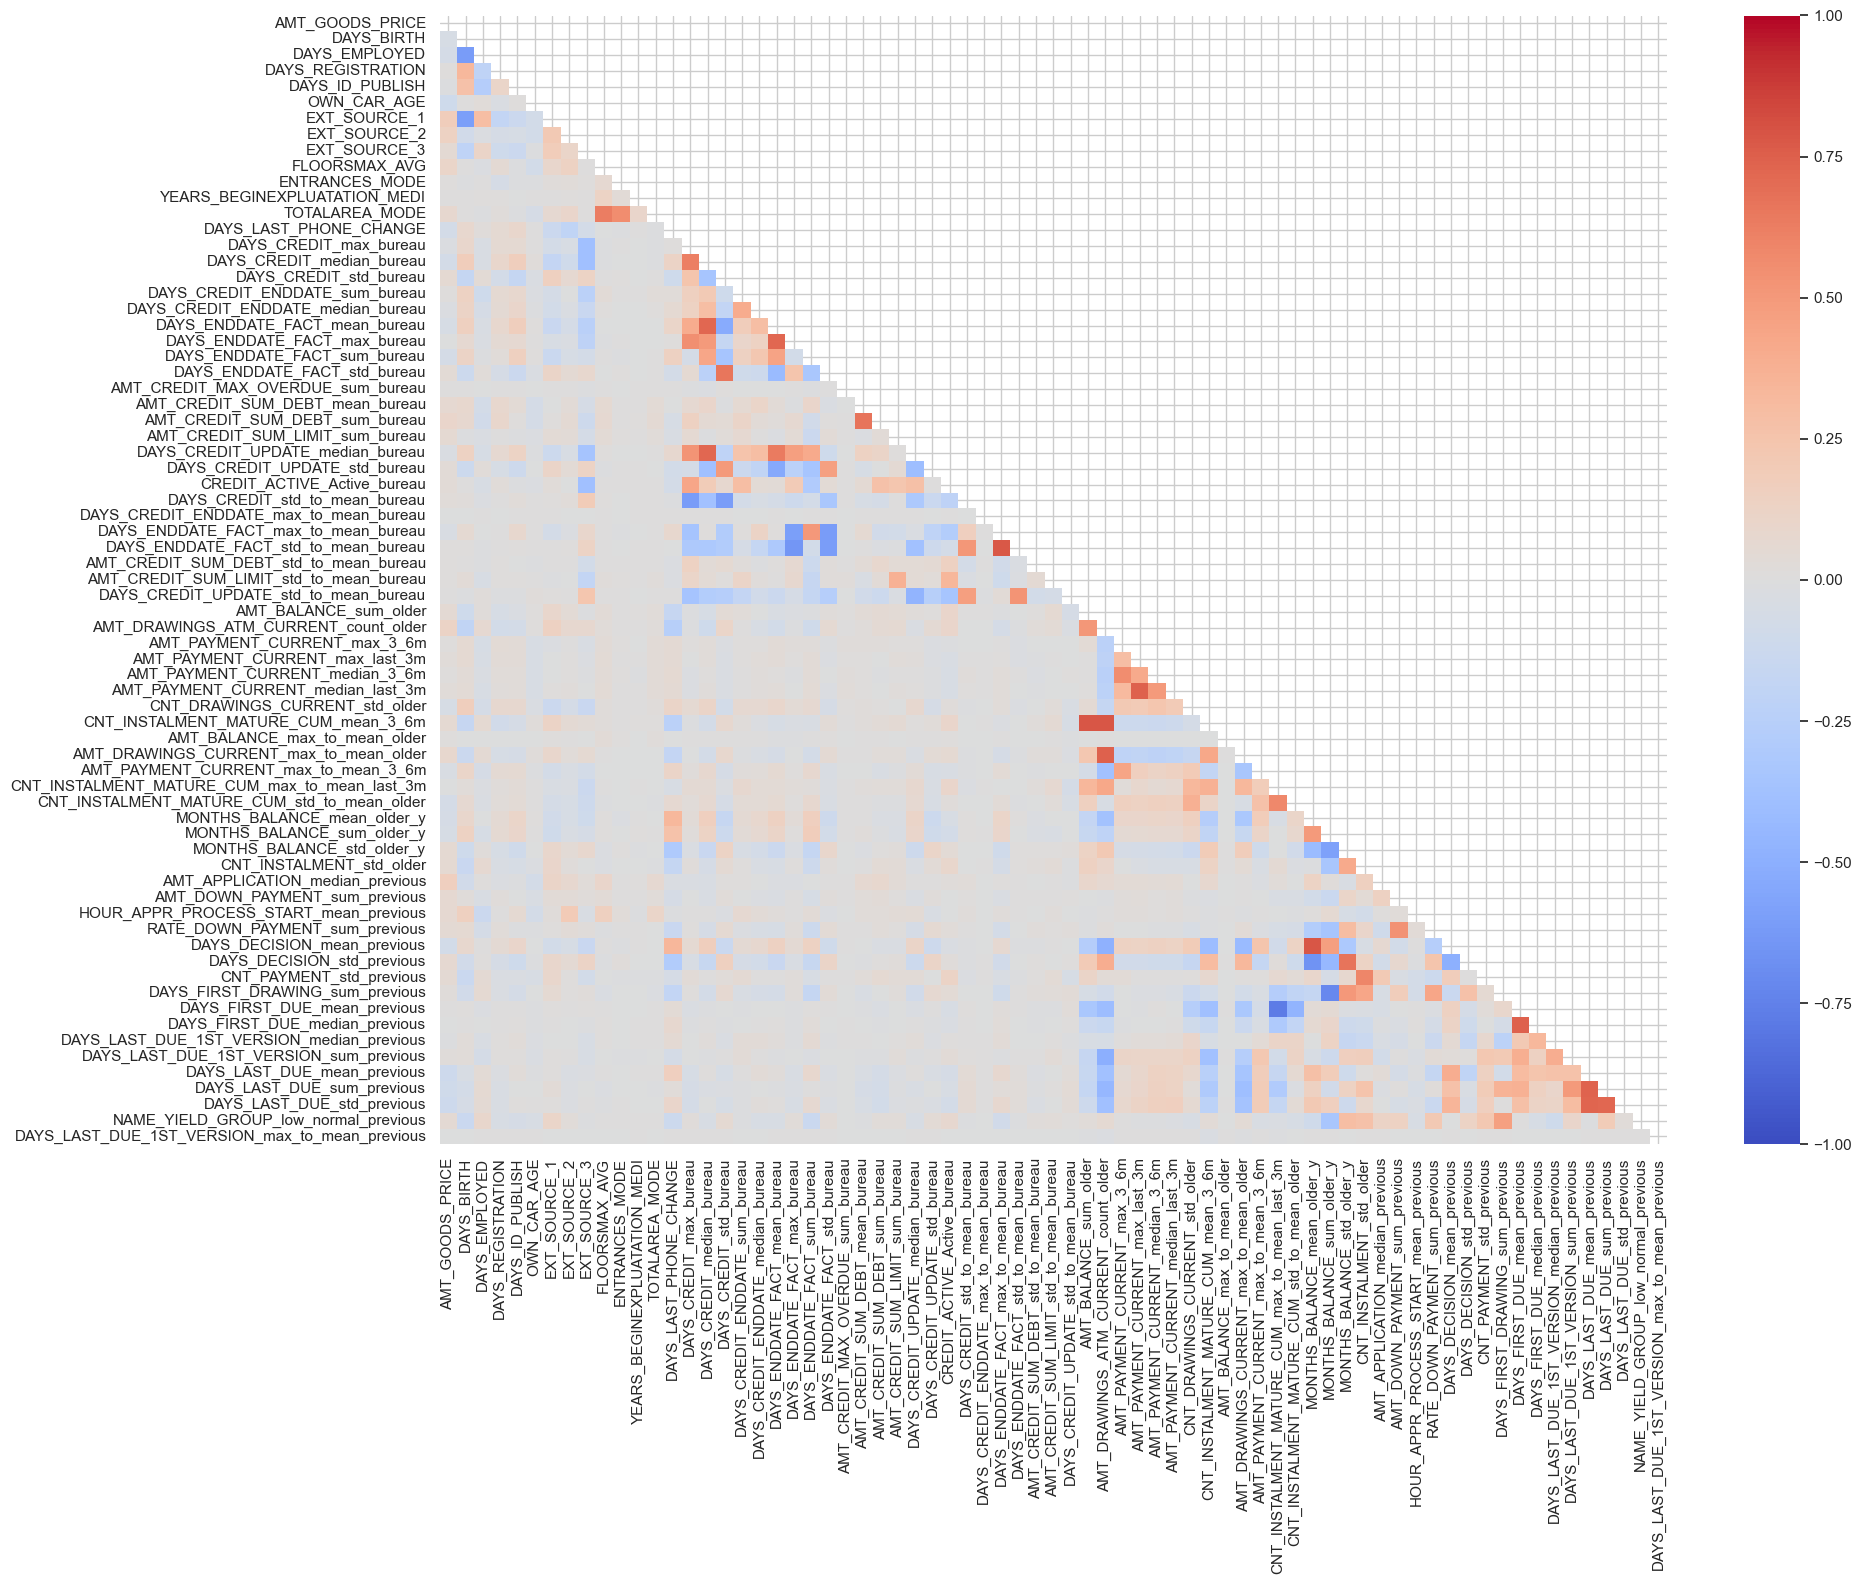

In [21]:
new_corr = final.drop(["TARGET", "SK_ID_CURR"], axis=1).select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(new_corr, dtype=bool))
plt.figure(figsize=(20, 16))
sns.heatmap(new_corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

In [19]:
del final_df_without_low_iv, summary, corr, pairs, high_corr

In [20]:
gc.collect()

252

In [21]:
# on the remaining features we can apply Boruta to select the top N_FEATURES_TO_SELECT features, this will be our final set of features for modeling
# we do that on a subset of the data to speed it up
X = pd.get_dummies(final_df.drop(["TARGET", "SK_ID_CURR"], axis=1))
feature_names = X.columns
X = X.fillna(-99999999)
y = final_df["TARGET"].values

In [22]:
rf = RandomForestClassifier(
    n_jobs=-1,
    class_weight="balanced",
    max_depth=8,
    random_state=RANDOM_SEED
)
# subsample 20,000 rows - we run it twice with different random states to get a more robust set of features, we will take the intersection of the two sets of confirmed features
X_sample, y_sample = resample(X, y, n_samples=20000, random_state=RANDOM_SEED, stratify=y)
boruta = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    max_iter=50,
    random_state=RANDOM_SEED
)
boruta.fit(X_sample.values, y_sample)
confirmed = feature_names[boruta.support_].tolist()
tentative = feature_names[boruta.support_weak_].tolist()
print(f"Confirmed: {len(confirmed)} features")
print(confirmed)
print(f"\nTentative: {len(tentative)} features")
print(tentative)
X_sample_2, y_sample_2 = resample(X, y, n_samples=20000, random_state=RANDOM_SEED + 1, stratify=y)
boruta_2 = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    max_iter=50,
    random_state=RANDOM_SEED
)
boruta_2.fit(X_sample_2.values, y_sample_2)
confirmed_2 = feature_names[boruta_2.support_].tolist()
tentative_2 = feature_names[boruta_2.support_weak_].tolist()
print(f"Confirmed: {len(confirmed_2)} features")
print(confirmed_2)
print(f"\nTentative: {len(tentative_2)} features")
print(tentative_2)

Confirmed: 42 features
['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TOTALAREA_MODE', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_CREDIT_mean_bureau', 'DAYS_CREDIT_max_bureau', 'DAYS_CREDIT_sum_bureau', 'DAYS_CREDIT_median_bureau', 'DAYS_CREDIT_std_bureau', 'DAYS_CREDIT_ENDDATE_mean_bureau', 'DAYS_ENDDATE_FACT_std_bureau', 'AMT_CREDIT_SUM_mean_bureau', 'AMT_CREDIT_SUM_median_bureau', 'AMT_CREDIT_SUM_DEBT_mean_bureau', 'AMT_CREDIT_SUM_DEBT_median_bureau', 'DAYS_CREDIT_UPDATE_mean_bureau', 'DAYS_CREDIT_UPDATE_median_bureau', 'DAYS_CREDIT_UPDATE_std_bureau', 'DAYS_CREDIT_max_to_mean_bureau', 'DAYS_CREDIT_std_to_mean_bureau', 'DAYS_CREDIT_ENDDATE_max_to_mean_bureau', 'DAYS_CREDIT_ENDDATE_std_to_mean_bureau', 'MONTHS_BALANCE_std_older_y', 'MONTHS_BALANCE_max_to_mean_older_y', 'DAYS_DECISION_mean_previous', 'DAYS_DECISION_median_previous', 'CNT_PAYMENT_std_previous', 'DAYS_FIRST_DUE

In [23]:
set1 = set(confirmed + tentative)
set2 = set(confirmed_2 + tentative_2)
only_in_first = set1 - set2
only_in_second = set2 - set1
print(f"Only in first run: {only_in_first}")
print(f"Only in second run: {only_in_second}")
print(f"\nIn both: {len(set1 & set2)} features")

Only in first run: {'AMT_CREDIT_SUM_DEBT_mean_bureau', 'AMT_CREDIT_SUM_mean_bureau', 'DAYS_DECISION_median_previous', 'TOTALAREA_MODE', 'DAYS_CREDIT_sum_bureau', 'DAYS_FIRST_DUE_sum_previous', 'DAYS_LAST_DUE_sum_previous', 'DAYS_DECISION_sum_previous', 'DAYS_CREDIT_ENDDATE_max_to_mean_bureau', 'MONTHS_BALANCE_std_older_y', 'AMT_CREDIT_SUM_DEBT_median_bureau', 'DAYS_CREDIT_max_to_mean_bureau', 'AMT_CREDIT_SUM_median_bureau', 'DAYS_LAST_DUE_1ST_VERSION_max_to_mean_previous', 'DAYS_CREDIT_ENDDATE_std_to_mean_bureau'}
Only in second run: {'MONTHS_BALANCE_sum_older_y', 'MONTHS_BALANCE_std_to_mean_older_y', 'CNT_INSTALMENT_MATURE_CUM_max_to_mean_last_3m', 'AMT_DOWN_PAYMENT_max_previous', 'NAME_PRODUCT_TYPE_walk-in_previous', 'DAYS_CREDIT_ENDDATE_max_bureau', 'NAME_EDUCATION_TYPE_Higher education', 'AMT_DOWN_PAYMENT_median_previous', 'CNT_PAYMENT_mean_previous', 'AMT_DOWN_PAYMENT_sum_previous', 'AMT_DOWN_PAYMENT_mean_previous', 'DAYS_CREDIT_UPDATE_std_to_mean_bureau', 'CNT_INSTALMENT_FUTURE_s

In [24]:
final_features = list(set(confirmed + tentative + confirmed_2 + tentative_2))
print(f"{len(final_features)} features selected")
print(final_features)

59 features selected
['AMT_CREDIT_SUM_DEBT_mean_bureau', 'NAME_CONTRACT_STATUS_Refused_previous', 'DAYS_CREDIT_median_bureau', 'TOTALAREA_MODE', 'DAYS_DECISION_median_previous', 'DAYS_CREDIT_UPDATE_std_to_mean_bureau', 'AMT_DOWN_PAYMENT_max_previous', 'DAYS_CREDIT_UPDATE_mean_bureau', 'AMT_CREDIT_SUM_DEBT_median_bureau', 'CODE_GENDER_F', 'DAYS_EMPLOYED', 'DAYS_CREDIT_max_to_mean_bureau', 'AMT_DOWN_PAYMENT_median_previous', 'EXT_SOURCE_2', 'DAYS_CREDIT_mean_bureau', 'DAYS_CREDIT_max_bureau', 'EXT_SOURCE_3', 'DAYS_CREDIT_ENDDATE_std_to_mean_bureau', 'DAYS_REGISTRATION', 'CNT_PAYMENT_std_previous', 'AMT_CREDIT', 'EXT_SOURCE_1', 'DAYS_BIRTH', 'DAYS_CREDIT_ENDDATE_median_bureau', 'DAYS_CREDIT_UPDATE_median_bureau', 'DAYS_CREDIT_std_bureau', 'DAYS_LAST_DUE_sum_previous', 'NAME_PRODUCT_TYPE_walk-in_previous', 'DAYS_LAST_DUE_1ST_VERSION_median_previous', 'DAYS_CREDIT_ENDDATE_max_bureau', 'CNT_PAYMENT_mean_previous', 'AMT_ANNUITY', 'AMT_CREDIT_SUM_median_bureau', 'DAYS_LAST_PHONE_CHANGE', 'AMT_

In [25]:
ranking_df = pd.DataFrame({
    "feature": feature_names,
    "rank_1": boruta.ranking_,
    "rank_2": boruta_2.ranking_
})

ranking_df = ranking_df[ranking_df["feature"].isin(final_features)]
ranking_df["avg_rank"] = (ranking_df["rank_1"] + ranking_df["rank_2"]) / 2
ranking_df = ranking_df.sort_values("avg_rank")

print(ranking_df)

                                             feature  rank_1  rank_2  avg_rank
2                                         AMT_CREDIT       1       1       1.0
3                                        AMT_ANNUITY       1       1       1.0
4                                    AMT_GOODS_PRICE       1       1       1.0
6                                         DAYS_BIRTH       1       1       1.0
7                                      DAYS_EMPLOYED       1       1       1.0
8                                  DAYS_REGISTRATION       1       1       1.0
9                                    DAYS_ID_PUBLISH       1       1       1.0
27                                      EXT_SOURCE_1       1       1       1.0
28                                      EXT_SOURCE_2       1       1       1.0
29                                      EXT_SOURCE_3       1       1       1.0
77                            DAYS_LAST_PHONE_CHANGE       1       1       1.0
104                          DAYS_CREDIT_mean_bureau

In [30]:
final = final_df[ranking_df[0:N_FEATURES_TO_SELECT]["feature"].tolist() + ["TARGET", "SK_ID_CURR"]]

In [32]:
final.to_csv(DATA_DIR / "final_14_04.csv", index=False)

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [34]:
ratio = len(final[final[TARGET_COLUMN] == 0]) / len(final[final[TARGET_COLUMN] == 1])

for col in final.select_dtypes(include='object').columns:
    final[col] = final[col].astype('category')
X = final.drop(columns=[TARGET_COLUMN, 'SK_ID_CURR'])
y = final[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

In [ ]:
def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",

        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.13, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "subsample": trial.suggest_float("subsample", 0.3, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1),

        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 3),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", ratio - 0.01, ratio + 0.01),

        "tree_method": "hist"
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    aucs = []

    for train_idx, valid_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = XGBClassifier(
            **params,
            enable_categorical=True,
            early_stopping_rounds=50
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        aucs.append(model.best_score)

    return np.mean(aucs)

In [40]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)  
)

study.optimize(objective, n_trials=20)

[I 2026-04-13 21:24:07,381] A new study created in memory with name: no-name-91085799-ecf1-4940-9c90-42cc706f00b7
[I 2026-04-13 21:25:03,578] Trial 0 finished with value: 0.7505814367251838 and parameters: {'learning_rate': 0.047657531998729505, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.37624972742578533, 'colsample_bytree': 0.9472665917141514, 'gamma': 3.1486425891349117, 'reg_lambda': 4.172668371255836, 'reg_alpha': 0.20261279809401256, 'scale_pos_weight': 11.389677062189703}. Best is trial 0 with value: 0.7505814367251838.
[I 2026-04-13 21:26:21,032] Trial 1 finished with value: 0.7519376235464172 and parameters: {'learning_rate': 0.07217083321329693, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.4659925398096961, 'colsample_bytree': 0.694161468155265, 'gamma': 3.8718569103446443, 'reg_lambda': 1.383410179583408, 'reg_alpha': 1.0640858369354655, 'scale_pos_weight': 11.386533382424895}. Best is trial 1 with value: 0.7519376235464172.
[I 2026-04-13 21:26:59,758] Tr

In [ ]:
best_params = study.best_params
model = XGBClassifier(
    enable_categorical=True,
    **best_params,
    n_estimators=3000,
    tree_method="hist"
)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

NameError: name 'study' is not defined

In [35]:
with open(MODELS_DIR / "model.pkl", "rb") as f:
    model = pickle.load(f)

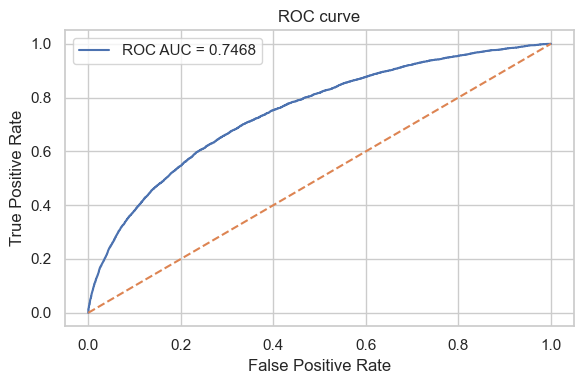

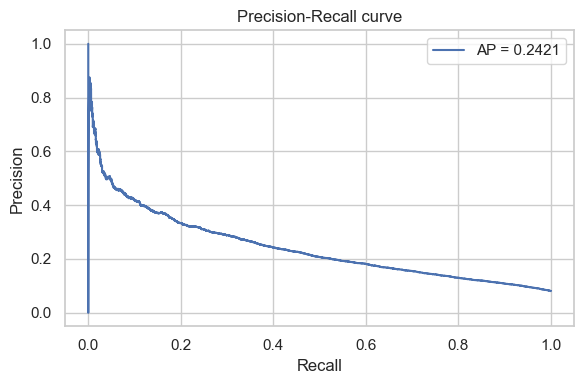

In [36]:
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]

# Wykres ROC

fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, test_proba):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f"AP = {average_precision_score(y_test, test_proba):.4f}")
ax.set_title("Precision-Recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
###############################################################################################################################
###############################################################################################################################
###############################################################################################################################

In [ ]:
# TODO: Evaluate the model

# TODO: Print Roc AUC

# TODO: Plot ROC curve


In [ ]:
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})

print(masterscale)

# TODO: Visualise the distribution of predicted probabilities and overlay the rating thresholds

# TODO: Decide the decision threshold (as the end of some rating), such will classify at least 10% as bad.

decision_threshold = None

In [ ]:
# TODO: Calculate the classification metrics

# TODO: Precision, recall, F1-score, confusion matrix, etc.

In [ ]:
# TODO: Plot SHAP summary plot

Provide a quick discussion how model works "globally"

## 6. Model Serialization

Save the trained model as a `.pkl` file in the `models/` directory.
This file **must be committed** to the repository.

In [ ]:
# Save model
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

# Verify: reload and check
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)
assert roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1]) == auc
print("Model verification passed!")

## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

In [ ]:
# TODO: Select interesting examples based on prediction probability

interesting_examples = None

### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [ ]:
# TODO: Implement DiCE counterfactual generation

### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [ ]:
# TODO: Implement Alibi counterfactual generation

## 8. Evaluation & Benchmarking

In [ ]:
# TODO: Implement DiCE counterfactual generation

## 9. Summary & Next Steps

### What you have done:

---

### AI Tools Used

Document any AI tools used during this project:

| Tool | How it was used |
|------|----------------|
| *e.g., ChatGPT* | *e.g., Helped debug LightGBM hyperparameter tuning* |
| | |